# Results

Data from `results/`, produced by `python tamper.py` and `python bench.py`.
Everything ran on one laptop with a local chain, so the numbers show relative behaviour, not production performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

tamper = pd.read_csv("results/tamper.csv")
summary = pd.read_csv("results/bench_summary.csv").drop_duplicates(["label", "ledger"], keep="last")
latency = pd.read_csv("results/bench_latency.csv")

NAMES = {
    ("instant blocks", "plain"): "PostgreSQL",
    ("instant blocks", "chained"): "PostgreSQL + hash chain",
    ("instant blocks", "contract"): "Smart contract, instant blocks",
    ("contract, 1 s blocks", "contract"): "Smart contract, 1 s blocks",
}
summary["setup"] = [NAMES.get((l, g), f"{g}, {l}") for l, g in zip(summary.label, summary.ledger)]
latency["setup"] = [NAMES.get((l, g), f"{g}, {l}") for l, g in zip(latency.label, latency.ledger)]

BLUE, INK, INK2, GRID, SURFACE = "#2a78d6", "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False,
})

Matplotlib is building the font cache; this may take a moment.


## 1. Tamper detection

An insider changes the first of three payments. `naive_edit` changes one stored value;
`full_rewrite` also fixes up everything else so the ledger is internally consistent.

In [2]:
tamper.set_index(["ledger", "attack"])

internal_check     witness
ledger   attack                                 
plain    naive_edit         no check  no witness
         full_rewrite       no check  no witness
chained  naive_edit         DETECTED      missed
         full_rewrite         missed    DETECTED
contract naive_edit         DETECTED      missed
         full_rewrite         missed    DETECTED

- PostgreSQL has nothing to check against.
- The hash chain and the smart contract behave the same: their own check catches a naive edit,
  and only the witness (an outside copy of the latest hash) catches a full rewrite.
- With a single operator the chain can be rolled back and replayed, so the blockchain alone does not prevent rewriting.

## 2. Latency: one payment at a time

In [3]:
summary[["setup", "payments", "p50_ms", "p95_ms", "mean_ms"]].set_index("setup")

,payments,p50_ms,p95_ms,mean_ms
setup,,,,
PostgreSQL,300,7.38,9.96,7.94
PostgreSQL + hash chain,300,8.24,11.67,9.06
"Smart contract, instant blocks",300,17.69,32.55,20.76
"Smart contract, 1 s blocks",20,983.17,999.51,983.49


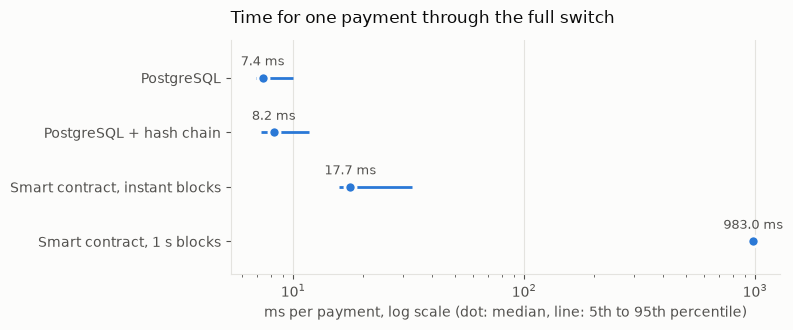

In [4]:
order = list(summary.setup)[::-1]
fig, ax = plt.subplots(figsize=(8, 3.4))
for y, name in enumerate(order):
    ms = latency[latency.setup == name].ms
    ax.hlines(y, ms.quantile(0.05), ms.quantile(0.95), color=BLUE, linewidth=2)
    ax.plot(ms.median(), y, "o", color=BLUE, markersize=8, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.annotate(f"{ms.median():.1f} ms", (ms.median(), y), xytext=(0, 9),
                textcoords="offset points", ha="center", color=INK2, fontsize=9)
ax.set_yticks(range(len(order)), order)
ax.set_xscale("log")
ax.set_ylim(-0.6, len(order) - 0.3)
ax.set_xlabel("ms per payment, log scale (dot: median, line: 5th to 95th percentile)")
ax.grid(axis="y", visible=False)
ax.set_title("Time for one payment through the full switch", loc="left", color=INK, pad=12)
plt.tight_layout()

- The two PostgreSQL ledgers are about equal; small differences between them are noise.
- The contract is a few times slower even with instant blocks on one laptop, the best case for a blockchain.
- With 1 s blocks every payment waits for the next block, so block time sets the latency.

## 3. Throughput: 8 customers paying at once

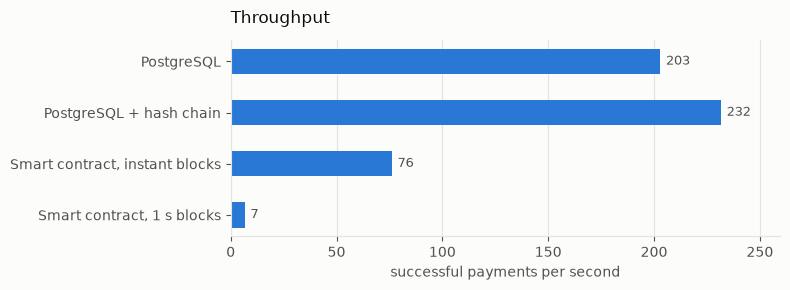

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.0))
rows = summary.iloc[::-1]
ax.set_axisbelow(True)
ax.barh(rows.setup, rows.parallel_per_second, color=BLUE, height=0.5)
ax.set_xlim(0, rows.parallel_per_second.max() * 1.12)
for y, v in enumerate(rows.parallel_per_second):
    ax.annotate(f"{v:.0f}", (v, y), xytext=(4, 0), textcoords="offset points", va="center", color=INK2, fontsize=9)
ax.set_xlabel("successful payments per second")
ax.grid(axis="y", visible=False)
ax.set_title("Throughput", loc="left", color=INK, pad=12)
plt.tight_layout()

## 4. Cost on the chain

In [6]:
summary[summary.ledger == "contract"][["setup", "gas_per_payment"]].set_index("setup")

,gas_per_payment
setup,
"Smart contract, instant blocks",58540.0
"Smart contract, 1 s blocks",58890.0


Each payment on the contract uses about 58 500 gas. On a private chain this is only a unit of work;
on a public chain every unit is paid for.

## Conclusion

1. Tamper evidence comes from a hash-linked history plus someone else holding the latest hash,
   not from a blockchain as such. PostgreSQL with a hash chain and a witness detects the same attacks.
2. A single-operator blockchain costs latency, throughput and gas, and can still be rewritten by its operator.
3. A blockchain adds something only when several independent organisations run nodes and validate,
   so the witness is built in. That is the case worth studying next.